Coefficients (θ): [[12.21509616]
 [23.77011339]]


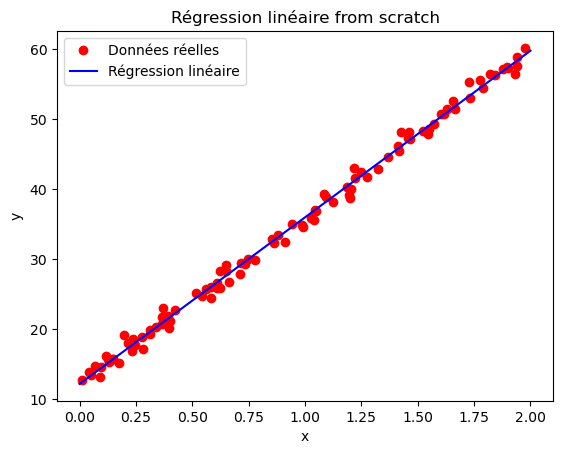

In [9]:
#Régression linéaire from scratch
#importation
import numpy as np
import matplotlib.pyplot as plt

# 1. Génération de données aléatoires
np.random.seed(42)

# Génère 100 points aléatoires pour x dans l'intervalle [0, 2]
x = 2 * np.random.rand(100, 1)

# Ajoute une constante pour représenter le biais (intercept)
x_new = np.c_[np.ones((100, 1)), x] 

# Génère les valeurs de y selon une relation linéaire y = 12 + 24 * x + bruit
y = 12 + 24 * x + np.random.randn(100, 1)

# 2. Calcul des coefficients θ (theta) avec l'équation normale
theta = np.linalg.inv(x_new.T.dot(x_new)).dot(x_new.T).dot(y)

# Affiche les coefficients trouvés (intercept et pente)
print("Coefficients (θ):", theta)

# 3. Visualisation des données et de la régression
# Tracé des données réelles (points rouges)
plt.plot(x, y, 'o', color='red', label='Données réelles')

# Génère une droite basée sur les coefficients trouvés
x_line = np.linspace(0, 2, 100).reshape(-1, 1)  
y_pred = theta[0] + theta[1] * x_line 

# Tracé de la droite de régression (ligne bleue)
plt.plot(x_line, y_pred, color='blue', label='Régression linéaire')

# Ajout de légendes et affichage
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Régression linéaire from scratch')
plt.show()


Erreur quadratique moyenne (MSE) : 0.99
Coefficient de détermination (R²) : 0.71
Ordonnée à l'origine (intercept) : 4.18
Coefficient (pente) : 3.04


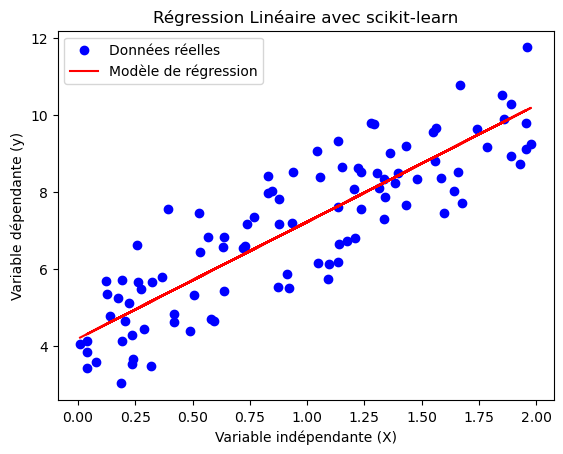

In [10]:
#Régression Linéaire avec scikit-learn
#importation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Génération de données simulées
np.random.seed(0)
X = 2 * np.random.rand(100, 1)  # Génère 100 valeurs entre 0 et 2
y = 4 + 3 * X + np.random.randn(100, 1)  # Génère y selon une relation linéaire avec du bruit

# Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Création et entraînement du modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.2f}")

# Affichage des coefficients du modèle
print(f"Ordonnée à l'origine (intercept) : {model.intercept_[0]:.2f}")
print(f"Coefficient (pente) : {model.coef_[0][0]:.2f}")

# Visualisation des résultats
plt.scatter(X, y, color='blue', label='Données réelles')  # Données réelles
plt.plot(X, model.predict(X), color='red', label='Modèle de régression')  # Droite de régression
plt.title("Régression Linéaire avec scikit-learn")
plt.xlabel("Variable indépendante (X)")
plt.ylabel("Variable dépendante (y)")
plt.legend()
plt.show()

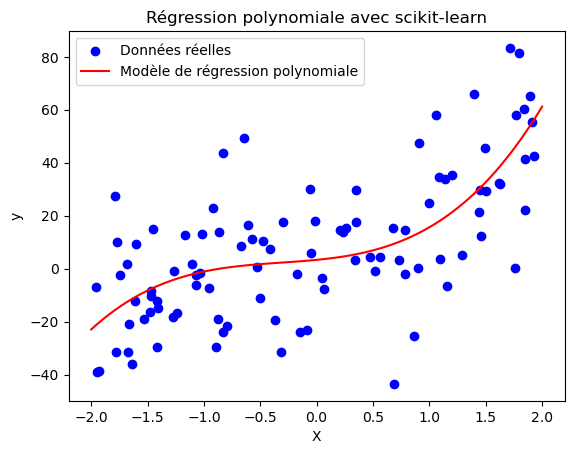

In [11]:
#Régression polynomiale avec scikit-learn
#importation
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 1. Génération de données simulées avec une relation polynomiale
X = 4 * np.random.rand(100, 1) - 2
y = 4 + 2 * X + 5 * X**2 + 6 * X**3 + 20 * np.random.randn(100, 1)

# 2. Transformation des caractéristiques pour la régression polynomiale
poly_features = PolynomialFeatures(degree=3, include_bias=False)  # Degré plus bas pour éviter le surajustement
X_poly = poly_features.fit_transform(X)

# 3. Création et entraînement du modèle de régression
reg = LinearRegression()
reg.fit(X_poly, y)

# 4. Préparation des données pour le tracé
X_vals = np.linspace(-2, 2, 100).reshape(-1, 1)
X_vals_poly = poly_features.transform(X_vals)
y_vals = reg.predict(X_vals_poly)

# 5. Visualisation des résultats
plt.scatter(X, y, color="blue", label="Données réelles")
plt.plot(X_vals, y_vals, color="red", label="Modèle de régression polynomiale")
plt.title("Régression polynomiale avec scikit-learn")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


θ0 (intercept) = [4.91061004]
θ1 = [2.82913734]
θ2 = [7.23977047]


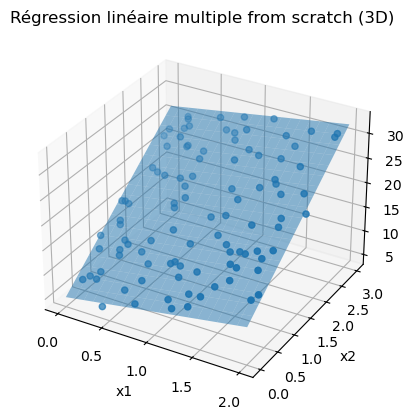

In [19]:
#Régression linéaire multiple from scratch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Génération des données
np.random.seed(42)

# Génération de deux variables explicatives
x1 = 2 * np.random.rand(100, 1)   # variable 1
x2 = 3 * np.random.rand(100, 1)   # variable 2

# Combiner les deux variables dans une matrice X
X = np.c_[x1, x2]

# Ajouter une colonne de 1 pour le biais (intercept θ0)
X_b = np.c_[np.ones((100, 1)), X]

# Génération de y avec une relation linéaire + bruit
# y = 5 + 3*x1 + 7*x2 + erreur
y = 5 + 3*x1 + 7*x2 + np.random.randn(100, 1)


# 2. Calcul des coefficients θ
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("θ0 (intercept) =", theta[0])
print("θ1 =", theta[1])
print("θ2 =", theta[2])


# 3. Visualisation 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Affichage des points réels
ax.scatter(x1, x2, y)

# Création d'une grille pour tracer le plan
x1_surf, x2_surf = np.meshgrid(
    np.linspace(0, 2, 20),
    np.linspace(0, 3, 20)
)

# Calcul des valeurs prédictes (plan)
y_surf = theta[0] + theta[1]*x1_surf + theta[2]*x2_surf

# Tracé du plan de régression
ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.5)

# Labels
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")

plt.title("Régression linéaire multiple from scratch (3D)")
plt.show()

Intercept (θ0) = [4.91061004]
θ1, θ2 = [[2.82913734 7.23977047]]


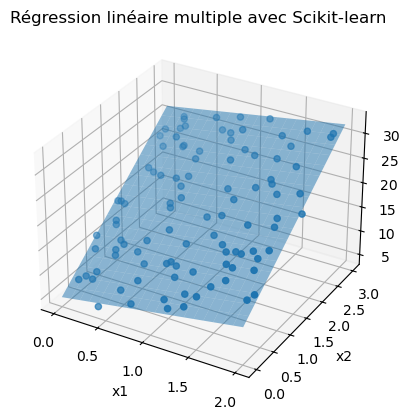

In [23]:
#Régression linéaire multiple avec Scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D


# 1. Génération des données
np.random.seed(42)

x1 = 2 * np.random.rand(100, 1)
x2 = 3 * np.random.rand(100, 1)

# Combiner les variables
X = np.c_[x1, x2]

# y = 5 + 3*x1 + 7*x2 + bruit
y = 5 + 3*x1 + 7*x2 + np.random.randn(100, 1)


# 2. Modèle Scikit-learn
model = LinearRegression()

# entraînement (fit)
model.fit(X, y)

# coefficients
print("Intercept (θ0) =", model.intercept_)
print("θ1, θ2 =", model.coef_)


# 3. Visualisation 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# données réelles
ax.scatter(x1, x2, y)

# grille pour surface
x1_surf, x2_surf = np.meshgrid(
    np.linspace(0, 2, 20),
    np.linspace(0, 3, 20)
)

# préparation pour prédiction
X_surf = np.c_[x1_surf.ravel(), x2_surf.ravel()]

# prédiction
y_surf = model.predict(X_surf)
y_surf = y_surf.reshape(x1_surf.shape)

# surface
ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.5)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")

plt.title("Régression linéaire multiple avec Scikit-learn")
plt.show()

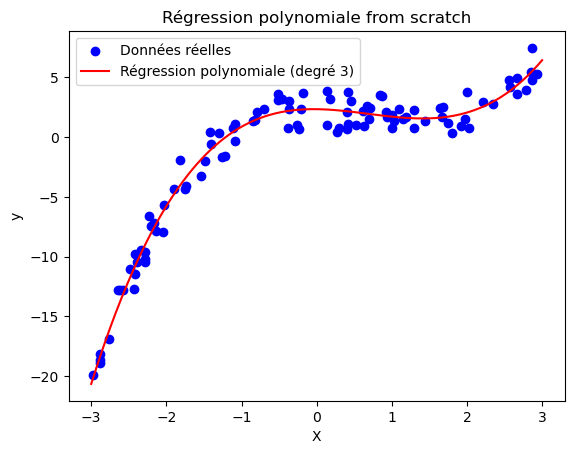

In [21]:
#Régression polynomiale from scratch
import numpy as np
import matplotlib.pyplot as plt

# Génération de données simulées
np.random.seed(0)
X = 6 * np.random.rand(100, 1) - 3  # Génère des valeurs entre -3 et 3
y = 0.5 * X**3 - X**2 + 2 + np.random.randn(100, 1)  # Relation non linéaire avec bruit

# Fonction pour ajouter des termes polynomiaux
def polynomial_features(X, degree):
    poly_features = X
    for d in range(2, degree + 1):
        poly_features = np.hstack((poly_features, X**d))
    return poly_features

# Création des caractéristiques polynomiales
degree = 3  # Degré du polynôme
X_poly = polynomial_features(X, degree)

# Ajout de la colonne de biais (1) pour le terme constant
X_poly = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]

# Régression normale (solution analytique)
theta = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)

# Prédictions
X_range = np.linspace(-3, 3, 300).reshape(-1, 1)  # Points pour le tracé
X_range_poly = polynomial_features(X_range, degree)  # Caractéristiques polynomiales
X_range_poly = np.c_[np.ones((X_range_poly.shape[0], 1)), X_range_poly]  # Ajout de biais
y_pred = X_range_poly.dot(theta)

# Visualisation
plt.scatter(X, y, color='blue', label="Données réelles")
plt.plot(X_range, y_pred, color='red', label=f"Régression polynomiale (degré {degree})")
plt.title("Régression polynomiale from scratch")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

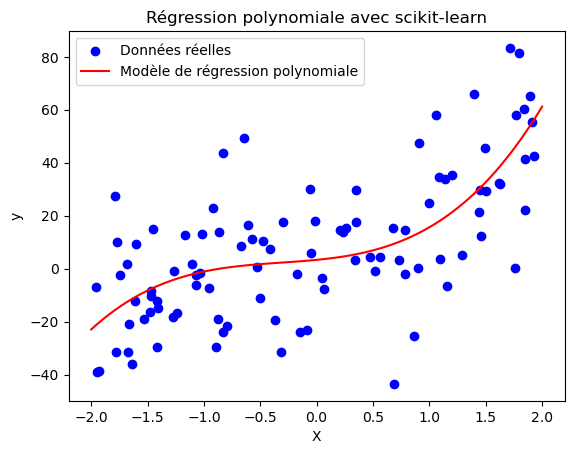

In [22]:
#Régression polynomiale avec scikit-learn
#importation
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 1. Génération de données simulées avec une relation polynomiale
X = 4 * np.random.rand(100, 1) - 2
y = 4 + 2 * X + 5 * X**2 + 6 * X**3 + 20 * np.random.randn(100, 1)

# 2. Transformation des caractéristiques pour la régression polynomiale
poly_features = PolynomialFeatures(degree=3, include_bias=False)  # Degré plus bas pour éviter le surajustement
X_poly = poly_features.fit_transform(X)

# 3. Création et entraînement du modèle de régression
reg = LinearRegression()
reg.fit(X_poly, y)

# 4. Préparation des données pour le tracé
X_vals = np.linspace(-2, 2, 100).reshape(-1, 1)
X_vals_poly = poly_features.transform(X_vals)
y_vals = reg.predict(X_vals_poly)

# 5. Visualisation des résultats
plt.scatter(X, y, color="blue", label="Données réelles")
plt.plot(X_vals, y_vals, color="red", label="Modèle de régression polynomiale")
plt.title("Régression polynomiale avec scikit-learn")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()